In [35]:
import pandas as pd

path = "../../data/raw/kathmandu_full_raw_2023_2024.csv"

data = pd.read_csv(path)

Lets visualize the correlation of PM2.5 at t with PM2.5 at (t-1), (t-2), ... (t-84)  
i.e. correlation of current PM2.5 with PM2.5 over the last 3.5 days.

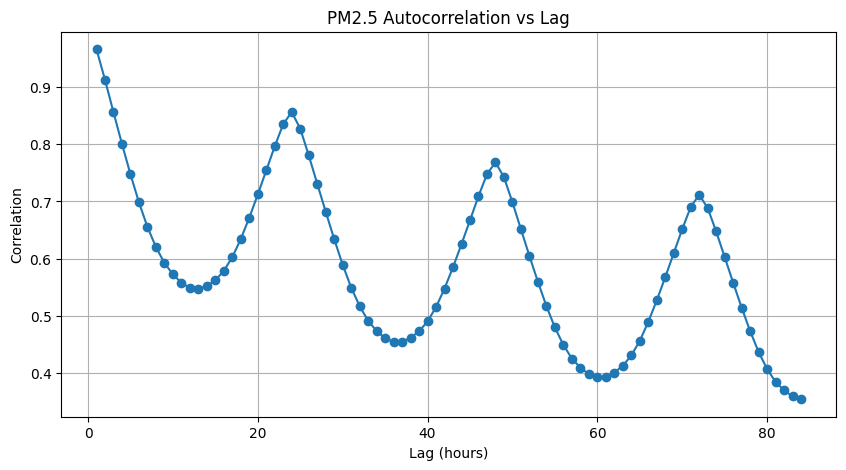

In [36]:
import numpy as np
import matplotlib.pyplot as plt

lags = np.arange(1, 85, 1)

correlations = []

for i in lags:
    corr = data["pm2_5"].corr(data["pm2_5"].shift(i))
    correlations.append(corr)

plt.figure(figsize=(10, 5))
plt.plot(lags, correlations, marker='o')

plt.xlabel("Lag (hours)")
plt.ylabel("Correlation")
plt.title("PM2.5 Autocorrelation vs Lag")

plt.grid(True)
plt.show()

The pattern of correlation is very similar after 24 hours lag, only getting weaker. Only data of the last 24 hours at max will be necessary as features.

Rolling mean and rolling sd (trend analysis).

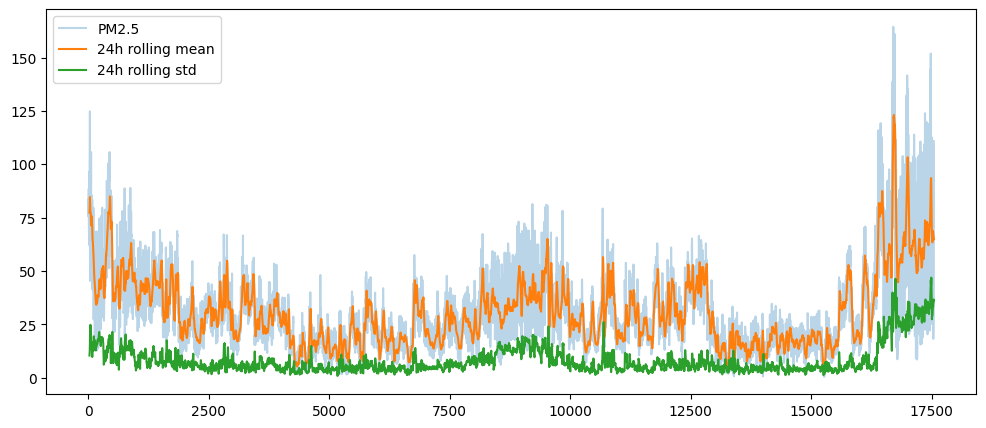

In [38]:
data["roll_24"] = data["pm2_5"].rolling(24).mean()
data["roll_std_24"] = data["pm2_5"].rolling(24).std()

plt.figure(figsize=(12,5))
plt.plot(data["pm2_5"], label="PM2.5", alpha=0.3)
plt.plot(data["roll_24"], label="24h rolling mean")
plt.plot(data["roll_std_24"], label="24h rolling std")
plt.legend()
plt.show()